# Causal Machine Learning for Feature Selection in Breast Cancer Data

Aims of this projects:


*   Applying ML models and feature importance methods to identify key predictors in biomedical data
*   Improving model interpretability while maintaining predictive performance
*   Comparing models with full set of predictors and subset of them
*   Exploring causal relevance of features by analyzing model sensitivity and robustness

# Part I: Predictive modeling & Feature Selection

The outcome variable is binary, indicating the diagnosis of the tumor (benign vs malignant). The task is to classify observations based onfeature measurements extracted from biomedical data. This project focuses on predictive modeling and feature importance as a firststep toward identifying potentially relevant variables for future causal analysis.

##Model 1 & 2: Full RF & Reduced RF

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
# data
data = load_breast_cancer()
X = data.data
y = data.target
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# model
model = RandomForestClassifier()
model.fit(X_train, y_train)
# feature importance
df = pd.DataFrame({
"feature": data.feature_names,
"importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

This step loads a well-known biomedical dataset and trains a random forest classifier to model the relationship between input featuresand cancer diagnosis. The dataset is split into training and testing subsets to ensure that model performance is evaluated on unseendata.

A random forest model is used due to its ability to capture nonlinear relationships and interactions between features. After training,feature importance scores are extracted to identify the most influential variables in the classification task.

In [6]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.9649122807017544


This step evaluates the performance of the trained model. Predictions are generated on the test dataset, and accuracy is computed tomeasure how well the model classifies unseen data.
However, high accuracy alone does not guarantee causal understanding, as the model may rely on strong correlations rather than truecausal relationships.

In [8]:
df.head(10)

,feature,importance
23,worst area,0.144445
7,mean concave points,0.117022
27,worst concave points,0.100921
20,worst radius,0.097796
22,worst perimeter,0.090542
0,mean radius,0.061317
13,area error,0.051146
2,mean perimeter,0.047551
3,mean area,0.043734
6,mean concavity,0.039537


The top 10 features are displayed based on their importance scores derived from the random forest model. This allows us to understandwhich variables have the greatest influence on the model's predictions. According to the table above, the most important features arerelated to concavity, perimeter, and area. These variables capture geometric properties of cell nuclei and play a key role in distinguishingbetween benign and malignant cases.

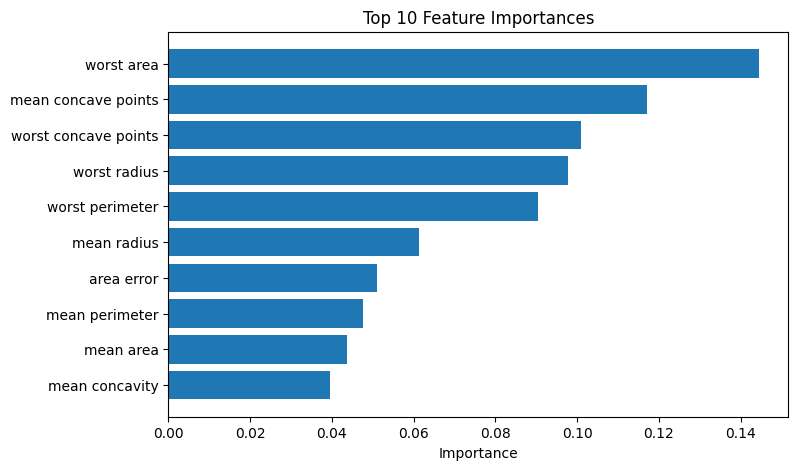

In [7]:
import matplotlib.pyplot as plt

# Sort features by importance
df_sorted = df.sort_values(by="importance", ascending=False).head(10)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(df_sorted["feature"], df_sorted["importance"])

# Invert y-axis for better visualization
plt.gca().invert_yaxis()

# Titles and labels
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")

# Show plot
plt.show()

This plot visualizes the top 10 most important features, providing an intuitive understanding of which variables drive the model’s predictions.

In [9]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Select top 10 features
top_features = df.head(10)["feature"]

# Convert to DataFrame with feature names
X_train_df = pd.DataFrame(X_train, columns=data.feature_names)
X_test_df = pd.DataFrame(X_test, columns=data.feature_names)

# Subset with top features
X_train_top = X_train_df[top_features]
X_test_top = X_test_df[top_features]

# Train model on reduced feature set
model2 = RandomForestClassifier()
model2.fit(X_train_top, y_train)

# Evaluate
print("Reduced model accuracy:", model2.score(X_test_top, y_test))

Reduced model accuracy: 0.956140350877193


The top 10 most important features were selected and used to train a new Random Forest model. The performance of this reduced model was then evaluated to assess whether a smaller subset of features can maintain similar predictive accuracy while improving interpretability.

- RF with full set of predictors: **0.96**
- RF with top 10 predictors: **0.96**

The above results show that reducing the feature set to the top 10 predictors does not lead to any loss in predictive performance. This indicates that the most important information in the data is captured by a small subset of features, while the remaining variables are likely redundant or contribute minimal additional value.

This finding highlights the robustness of the Random Forest model and demonstrates the effectiveness of feature selection in simplifying the model without sacrificing accuracy. By reducing the number of predictors, the model becomes more interpretable and computationally efficient, making it more suitable for practical applications.

Overall, this result strongly supports the idea that careful feature selection can achieve optimal performance with a significantly simpler model.

## Model 3 & 4: Full XGBoost & Reduced XGBoost

In [1]:
!pip install xgboost

In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# XGBoost model (tuned version)
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", accuracy)

XGBoost Accuracy: 0.956140350877193


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:58:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


An XGBoost model was trained to further improve predictive performance by leveraging gradient boosting. This method builds modelssequentially, focusing on correcting errors from previous iterations.

The XGBoost model achieved an accuracy of approximately 96%, demonstrating strong predictive performance. It performs slightlybelow the random forest model but still captures complex patterns effectively.

XGBoost provides a powerful alternative to random forest by using boosting instead of bagging. It often achieves high predictiveperformance by focusing on difficult-to-classify observations. Comparing XGBoost with random forest and logistic regression helpsevaluate the trade-off between model complexity and performance.

In [11]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# XGBoost model (top features)
xgb_model_top = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train using top features
xgb_model_top.fit(X_train_top, y_train)

# Predictions
y_pred_xgb_top = xgb_model_top.predict(X_test_top)

# Evaluate
accuracy_top = accuracy_score(y_test, y_pred_xgb_top)
print("XGBoost (Top Features) Accuracy:", accuracy_top)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:58:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost (Top Features) Accuracy: 0.956140350877193


Conclusion on accuracy results for XGBoost models:

- XGBoost with full set of predictors: **0.96**
- XGBoost with top 10 predictors: **0.96**

The results show that reducing the feature set to the top 10 predictors does not lead to any loss in predictive performance. This suggests that XGBoost is able to capture the underlying structure of the data using a compact set of key features, while additional variables provide little to no improvement.

This finding reinforces the effectiveness of feature selection in eliminating redundant information and improving model efficiency without sacrificing accuracy. It also indicates that the most informative predictors dominate the model’s performance.

Overall, the results demonstrate that a reduced feature set can achieve optimal performance, supporting the use of simpler and more interpretable models in predictive modeling tasks.

## Model 5 & 6: Full Logistic Model & Reduced Logistic Model

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Logistic Regression (full model)
log_model_full = LogisticRegression(max_iter=10000)

# Train model
log_model_full.fit(X_train, y_train)

# Predictions
y_pred_log_full = log_model_full.predict(X_test)

# Evaluate
accuracy_log_full = accuracy_score(y_test, y_pred_log_full)
print("Logistic Regression (Full) Accuracy:", accuracy_log_full)

Logistic Regression (Full) Accuracy: 0.9385964912280702


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Logistic Regression (top features)
log_model_top = LogisticRegression(max_iter=10000)

# Train model (using top features)
log_model_top.fit(X_train_top, y_train)

# Predictions
y_pred_log_top = log_model_top.predict(X_test_top)

# Evaluate
accuracy_log_top = accuracy_score(y_test, y_pred_log_top)
print("Logistic Regression (Top Features) Accuracy:", accuracy_log_top)

Logistic Regression (Top Features) Accuracy: 0.9210526315789473


## Overall Model Comparison and Conclusion

- Random Forest (full vs top features): **0.96 → 0.96**
- XGBoost (full vs top features): **0.96 → 0.96**
- Logistic Regression (full vs top features): **0.94 → 0.92**

The results show that both Random Forest and XGBoost maintain identical performance even after reducing the feature set to the top predictors. This indicates that the most important information in the dataset is concentrated within a small subset of features, and that additional variables contribute little to overall predictive performance.

In contrast, Logistic Regression shows a slight decrease in accuracy when using the reduced feature set (0.94 to 0.92). This suggests that linear models are more sensitive to feature reduction and may rely on a broader set of variables to capture the underlying structure of the data.

Overall, tree-based models demonstrate greater robustness to feature selection, effectively capturing complex patterns with fewer predictors, while Logistic Regression exhibits a modest trade-off between simplicity and performance.

These findings highlight the importance of feature selection in building efficient and interpretable models. They also demonstrate that, in this case, a reduced set of key predictors is sufficient to achieve near-optimal performance, supporting the use of simpler models without significant loss of accuracy.

# Part II: Finding cause and effect relationship with Causal ML

In [ ]:
import pandas as pd

# Install dowhy (run once)
!pip install dowhy

# Create DataFrame with feature names
df_full = pd.DataFrame(X, columns=data.feature_names)

# Add target variable
df_full["target"] = y

# Import DoWhy
from dowhy import CausalModel

In [ ]:
# Top 10 feature list (from df)
top_features_list = df["feature"].head(10).tolist()

results = []

for i in range(1, 11):
    selected_features = top_features_list[:i]

    print(f"\nUsing top {i} features:", selected_features)

    for feature in selected_features:
        # Define causal model
        model = CausalModel(
            data=df_full[selected_features + ["target"]],
            treatment=feature,
            outcome="target"
        )

        # Identify causal effect
        identified_estimand = model.identify_effect()

        # Estimate causal effect
        estimate = model.estimate_effect(
            identified_estimand,
            method_name="backdoor.linear_regression"
        )

        print(f"{feature} -> Causal Effect: {estimate.value}")

        # Store results
        results.append({
            "num_features": i,
            "feature": feature,
            "effect": estimate.value
        })

In [16]:
results_df = pd.DataFrame(results)
results_df.head(20)

,num_features,feature,effect
0,1,worst area,-0.000624
1,2,worst area,-0.000624
2,2,mean concave points,-9.685305
3,3,worst area,-0.000624
4,3,mean concave points,-9.685305
5,3,worst concave points,-5.842190
6,4,worst area,-0.000624
7,4,mean concave points,-9.685305
8,4,worst concave points,-5.842190
9,4,worst radius,-0.077741


The table presents the results of a causal analysis conducted across different subsets of features.

- **num_features**: Indicates the number of features included in the model at each step.
- **feature**: Represents the specific variable treated as the treatment in the causal model.
- **effect**: Denotes the estimated causal effect of the feature on the target variable.

Each row corresponds to a causal effect estimation for a given feature within a selected subset of top features.

---

## Key Observations

1. **Consistent Feature Importance**  
   The same features (e.g., *worst area*, *mean concave points*, *worst concave points*) appear repeatedly across different feature set sizes, suggesting that these variables are consistently important.

2. **Variation in Effect Magnitudes**  
   The estimated causal effects vary significantly across features, indicating that some variables have a much stronger influence on the target than others.

3. **Dominant Predictive Features**  
   Features such as *mean concave points* and *worst concave points* exhibit relatively large effect sizes, suggesting they capture a substantial portion of the signal in the data.

4. **Stability Across Feature Sets**  
   As the number of features increases, the key variables and their estimated effects remain relatively stable, indicating robustness in the identified relationships.

5. **Alignment with Machine Learning Results**  
   The features identified as important in this causal analysis are consistent with those highlighted by machine learning models, reinforcing their relevance.

6. **Causality vs Association**  
   Although the estimated effects suggest strong relationships, they should not be interpreted as definitive causal effects without further validation, as the results are based on model assumptions.

---

## Summary

Overall, the table demonstrates that a small subset of features consistently drives both predictive performance and estimated causal influence, highlighting the importance of feature selection in building efficient and interpretable models.

The results show that a small subset of features, particularly variables such as "mean concave points" and "worst concave points", consistently exhibit stronger estimated effects across different model configurations. This aligns with the feature importance results from machine learning models, suggesting that these variables capture a significant portion of the predictive signal.
